# Lab-4: Applied Statistical Modeling & Interactive Web Dashboard
## Complete Analysis Using the Provided Medical Insurance Dataset

**Course:** Statistical Modeling with Python  
**Program:** M.Sc. Data Science — Semester 1  
**Dataset file:** `insurance(1).csv`

This notebook is specifically prepared for the dataset provided with this submission.

### Dataset Features
- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`
- `charges`

### Assignment Tasks Covered
1. Exploratory Data Analysis
2. Descriptive Metrics
3. Hypothesis Test 1: Two-Group Comparison
4. Hypothesis Test 2: Chi-Square Association Test
5. Multiple Linear Regression using OLS
6. Coefficient and Model-Fit Interpretation
7. Residual Diagnostics
8. Normality Diagnostics
9. Multicollinearity using VIF
10. Prediction with Confidence and Prediction Intervals


## 1. Import Libraries

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from scipy.stats import chi2_contingency, jarque_bera

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the Provided Dataset

In [4]:
df = pd.read_csv(r"C:\Users\Raaj Soni\OneDrive\Desktop\Stats\insurance.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head()


Dataset loaded successfully!
Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Dataset Inspection and Data Quality

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset information:")
df.info()


Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


Missing values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Duplicate rows: 1

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


## Part 1 — Exploratory Data Analysis & Hypothesis Testing

### 4. Descriptive Metrics

In [6]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

summary = pd.DataFrame(index=numerical_cols)
summary["Mean"] = df[numerical_cols].mean()
summary["Median"] = df[numerical_cols].median()
summary["Standard Deviation"] = df[numerical_cols].std()
summary["Q1"] = df[numerical_cols].quantile(0.25)
summary["Q3"] = df[numerical_cols].quantile(0.75)
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary["Skewness"] = df[numerical_cols].skew()
summary["Kurtosis"] = df[numerical_cols].kurtosis()

display(summary.round(4))


,Mean,Median,Standard Deviation,Q1,Q3,IQR,Skewness,Kurtosis
age,39.2070,39.000,14.0500,27.0000,51.0000,24.0000,0.0557,-1.2451
bmi,30.6634,30.400,6.0982,26.2962,34.6938,8.3975,0.2840,-0.0507
children,1.0949,1.000,1.2055,0.0000,2.0000,2.0000,0.9384,0.2025
charges,13270.4223,9382.033,12110.0112,4740.2872,16639.9125,11899.6254,1.5159,1.6063


### 5. Distribution Plots — Histograms and KDE

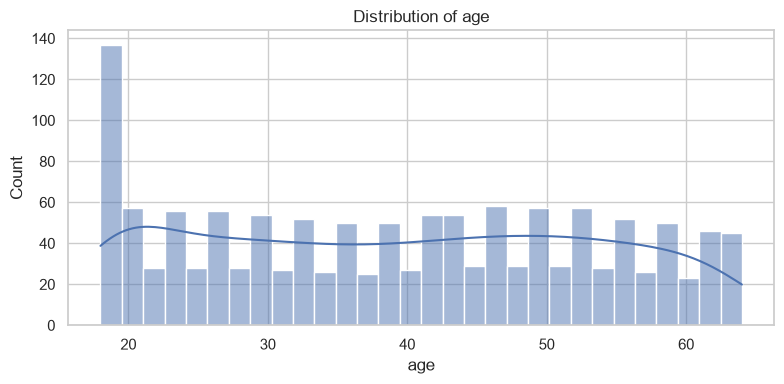

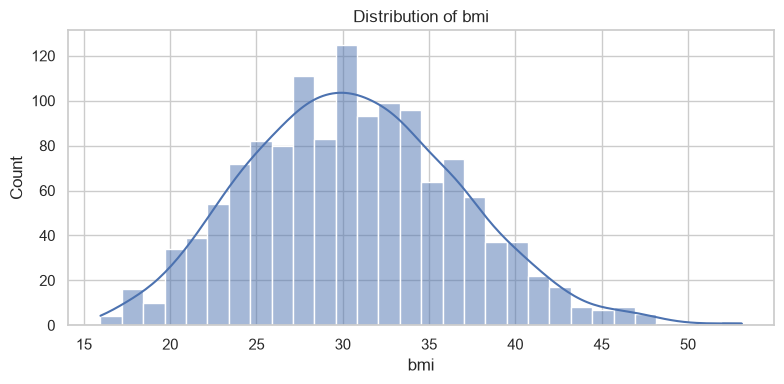

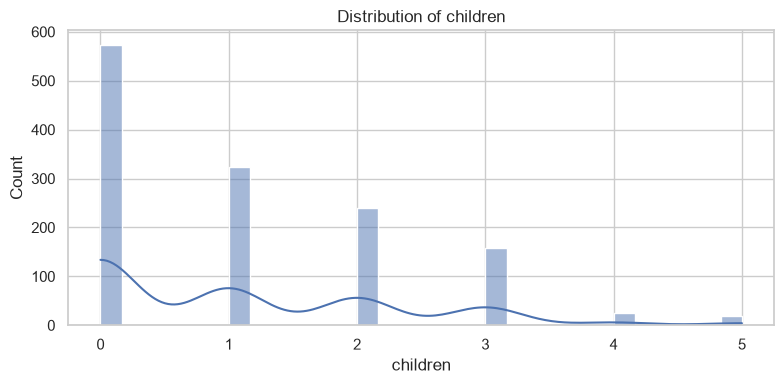

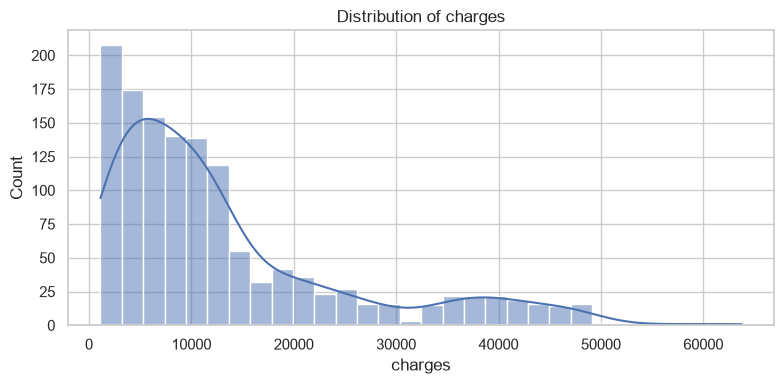

In [7]:
for column in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, bins=30, kde=True)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()


### 6. Categorical Variables


Frequency table for sex:


sex
male      676
female    662
Name: count, dtype: int64

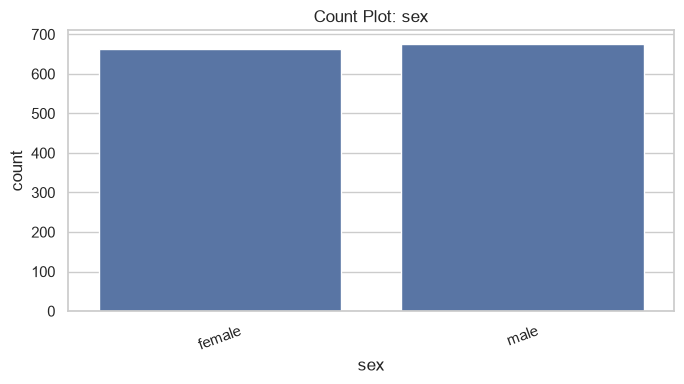


Frequency table for smoker:


smoker
no     1064
yes     274
Name: count, dtype: int64

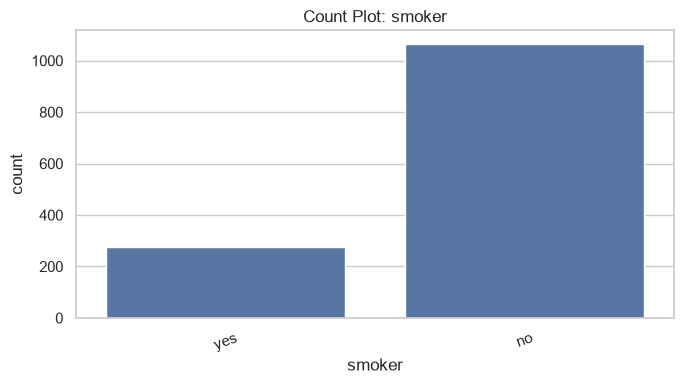


Frequency table for region:


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

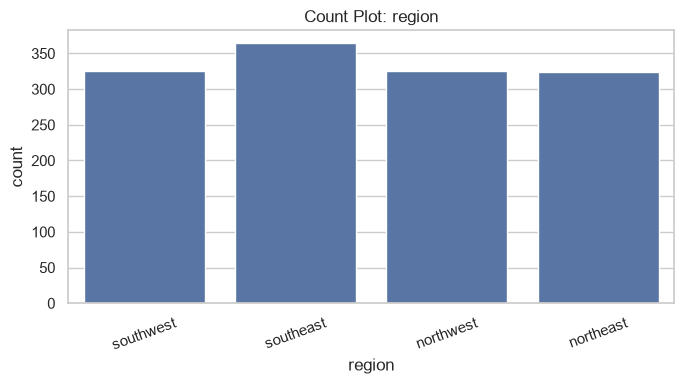

In [8]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for column in categorical_cols:
    print(f"\nFrequency table for {column}:")
    display(df[column].value_counts())

    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=column)
    plt.title(f"Count Plot: {column}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


### 7. Bivariate Visual Exploration

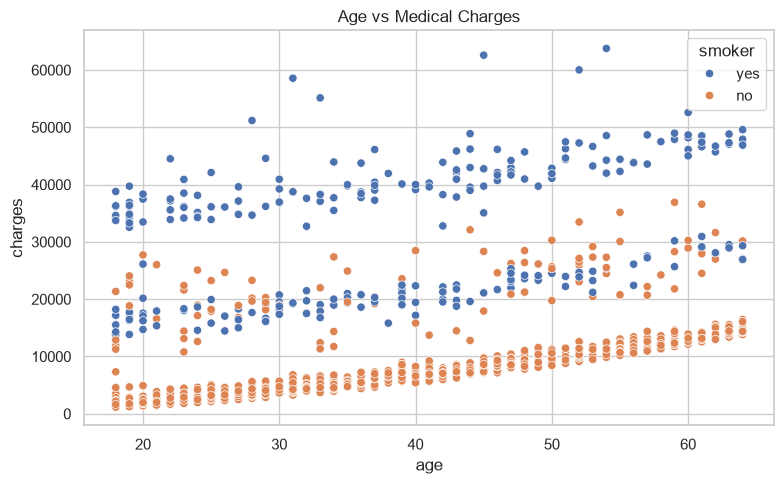

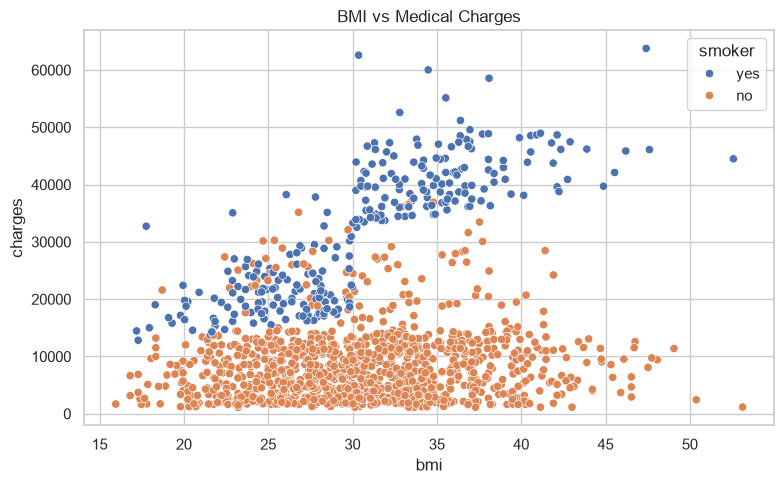

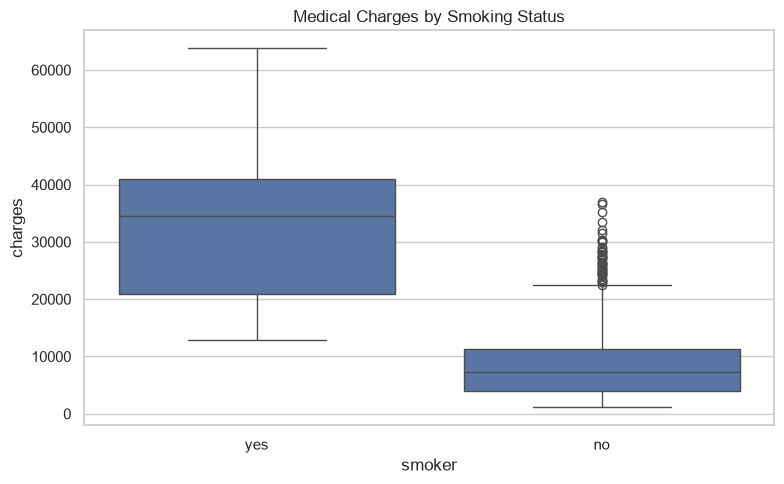

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Medical Charges")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Medical Charges")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Medical Charges by Smoking Status")
plt.tight_layout()
plt.show()


### 8. Correlation Matrix

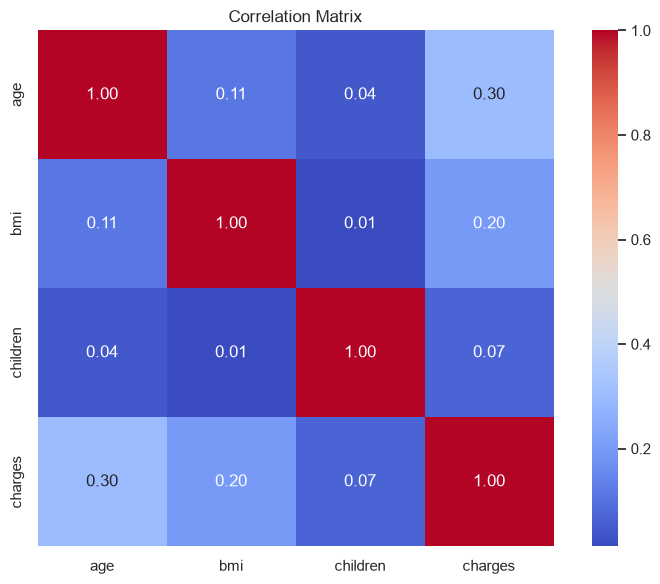

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [10]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(3))


# Hypothesis Test 1 — Smokers vs Non-Smokers

## Research Question
Do smokers and non-smokers have significantly different medical charges?

### Hypotheses
- **H₀:** There is no significant difference in medical charges between smokers and non-smokers.
- **H₁:** There is a significant difference in medical charges between smokers and non-smokers.

Significance level: **α = 0.05**


In [11]:
alpha = 0.05

smoker_charges = df.loc[df["smoker"].str.lower() == "yes", "charges"].dropna()
nonsmoker_charges = df.loc[df["smoker"].str.lower() == "no", "charges"].dropna()

group_summary = pd.DataFrame({
    "Smokers": smoker_charges.describe(),
    "Non-Smokers": nonsmoker_charges.describe()
})

display(group_summary)


,Smokers,Non-Smokers
count,274.000000,1064.000000
mean,32050.231832,8434.268298
std,11541.547176,5993.781819
min,12829.455100,1121.873900
25%,20826.244213,3986.438700
50%,34456.348450,7345.405300
75%,41019.207275,11362.887050
max,63770.428010,36910.608030


### 9. Normality Check — Shapiro-Wilk Test

In [12]:
shapiro_smoker = shapiro(smoker_charges)
shapiro_nonsmoker = shapiro(nonsmoker_charges)

normality = pd.DataFrame({
    "Group": ["Smokers", "Non-Smokers"],
    "Shapiro Statistic": [
        shapiro_smoker.statistic,
        shapiro_nonsmoker.statistic
    ],
    "p-value": [
        shapiro_smoker.pvalue,
        shapiro_nonsmoker.pvalue
    ]
})

display(normality)

if (shapiro_smoker.pvalue > alpha and
        shapiro_nonsmoker.pvalue > alpha):
    print("Both groups satisfy the normality criterion at α = 0.05.")
else:
    print("At least one group does not satisfy the normality criterion.")


,Group,Shapiro Statistic,p-value
0,Smokers,0.939552,3.624990e-09
1,Non-Smokers,0.872864,1.445901e-28


At least one group does not satisfy the normality criterion.


### 10. Equal Variance Check — Levene's Test

In [13]:
levene_result = levene(smoker_charges, nonsmoker_charges)

print("Levene Statistic:", round(levene_result.statistic, 6))
print("p-value:", levene_result.pvalue)

if levene_result.pvalue > alpha:
    print("Fail to reject the equal-variance assumption.")
else:
    print("Evidence against equal variances.")


Levene Statistic: 332.613516
p-value: 1.5593284881791394e-66
Evidence against equal variances.


### 11. Run the Appropriate Two-Group Test

In [14]:
both_normal = (
    shapiro_smoker.pvalue > alpha and
    shapiro_nonsmoker.pvalue > alpha
)

if both_normal:
    equal_variance = levene_result.pvalue > alpha

    test = ttest_ind(
        smoker_charges,
        nonsmoker_charges,
        equal_var=equal_variance
    )

    test_name = "Two-Sample t-Test"
    statistic = test.statistic
    p_value = test.pvalue

else:
    test = mannwhitneyu(
        smoker_charges,
        nonsmoker_charges,
        alternative="two-sided"
    )

    test_name = "Mann-Whitney U Test"
    statistic = test.statistic
    p_value = test.pvalue

print("Test Used:", test_name)
print("Test Statistic:", statistic)
print("p-value:", p_value)

if p_value < alpha:
    print("\nFINAL CONCLUSION: Reject H₀.")
    print("There is a statistically significant difference in medical charges.")
else:
    print("\nFINAL CONCLUSION: Fail to Reject H₀.")
    print("There is insufficient evidence of a significant difference.")


Test Used: Mann-Whitney U Test
Test Statistic: 284133.0
p-value: 5.270233444503571e-130

FINAL CONCLUSION: Reject H₀.
There is a statistically significant difference in medical charges.


# Hypothesis Test 2 — Chi-Square Test

## Research Question
Is smoking status associated with geographic region?

### Hypotheses
- **H₀:** Smoking status and region are independent.
- **H₁:** Smoking status and region are associated.


In [15]:
contingency_table = pd.crosstab(df["smoker"], df["region"])

print("Contingency Table:")
display(contingency_table)

chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p_value_chi)

if p_value_chi < alpha:
    print("\nFINAL CONCLUSION: Reject H₀.")
    print("Smoking status and region are statistically associated.")
else:
    print("\nFINAL CONCLUSION: Fail to Reject H₀.")
    print("There is insufficient evidence of an association.")


Contingency Table:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,267,273,267
yes,67,58,91,58


Chi-Square Statistic: 7.34347776140707
Degrees of Freedom: 3
p-value: 0.06171954839170547

FINAL CONCLUSION: Fail to Reject H₀.
There is insufficient evidence of an association.


# Part 2 — Statistical Modeling & Diagnostic Checks

## 12. Multiple Linear Regression

Dependent variable:

**Y = charges**

Predictors include age, BMI, children, sex, smoking status, and region.

The model is:

**Y = β₀ + β₁X₁ + β₂X₂ + ... + βₖXₖ + ε**


In [16]:
# Convert categorical variables into dummy variables.
# drop_first=True prevents redundant dummy variables.

model_df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

X = model_df.drop(columns=["charges"])
y = model_df["charges"]

X = sm.add_constant(X)

print("Regression predictors:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Regression predictors:
['const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

X shape: (1338, 9)
y shape: (1338,)


### 13. Fit OLS Regression Model

In [17]:
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:33:55   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

### 14. Coefficients, p-values and 95% Confidence Intervals

In [18]:
confidence_intervals = model.conf_int()
confidence_intervals.columns = ["95% CI Lower", "95% CI Upper"]

results_table = pd.DataFrame({
    "Coefficient": model.params,
    "Standard Error": model.bse,
    "t-value": model.tvalues,
    "p-value": model.pvalues
}).join(confidence_intervals)

results_table["Significant at 0.05"] = results_table["p-value"] < 0.05

display(results_table.round(6))

print("R² =", round(model.rsquared, 4))
print("Adjusted R² =", round(model.rsquared_adj, 4))


,Coefficient,Standard Error,t-value,p-value,95% CI Lower,95% CI Upper,Significant at 0.05
const,-11938.538576,987.819175,-12.085753,0.000000,-13876.393424,-10000.683728,True
age,256.856353,11.898849,21.586655,0.000000,233.513778,280.198927,True
bmi,339.193454,28.599470,11.860131,0.000000,283.088426,395.298482,True
children,475.500545,137.804093,3.450555,0.000577,205.163286,745.837805,True
sex_male,-131.314359,332.945439,-0.394402,0.693348,-784.470270,521.841552,False
smoker_yes,23848.534542,413.153355,57.723202,0.000000,23038.030705,24659.038379,True
region_northwest,-352.963899,476.275786,-0.741091,0.458769,-1287.298203,581.370404,False
region_southeast,-1035.022049,478.692209,-2.162187,0.030782,-1974.096773,-95.947326,True
region_southwest,-960.050991,477.933024,-2.008756,0.044765,-1897.636383,-22.465600,True


R² = 0.7509
Adjusted R² = 0.7494


### 15. Significant Predictors

In [19]:
significant_predictors = results_table[
    results_table["p-value"] < alpha
]

print("Predictors statistically significant at α = 0.05:")
display(significant_predictors.round(5))


Predictors statistically significant at α = 0.05:


,Coefficient,Standard Error,t-value,p-value,95% CI Lower,95% CI Upper,Significant at 0.05
const,-11938.53858,987.81918,-12.08575,0.00000,-13876.39342,-10000.68373,True
age,256.85635,11.89885,21.58666,0.00000,233.51378,280.19893,True
bmi,339.19345,28.59947,11.86013,0.00000,283.08843,395.29848,True
children,475.50055,137.80409,3.45055,0.00058,205.16329,745.83780,True
smoker_yes,23848.53454,413.15335,57.72320,0.00000,23038.03071,24659.03838,True
region_southeast,-1035.02205,478.69221,-2.16219,0.03078,-1974.09677,-95.94733,True
region_southwest,-960.05099,477.93302,-2.00876,0.04476,-1897.63638,-22.46560,True


# Gauss-Markov Diagnostic Checks

### 16. Linearity & Homoscedasticity — Residuals vs Fitted

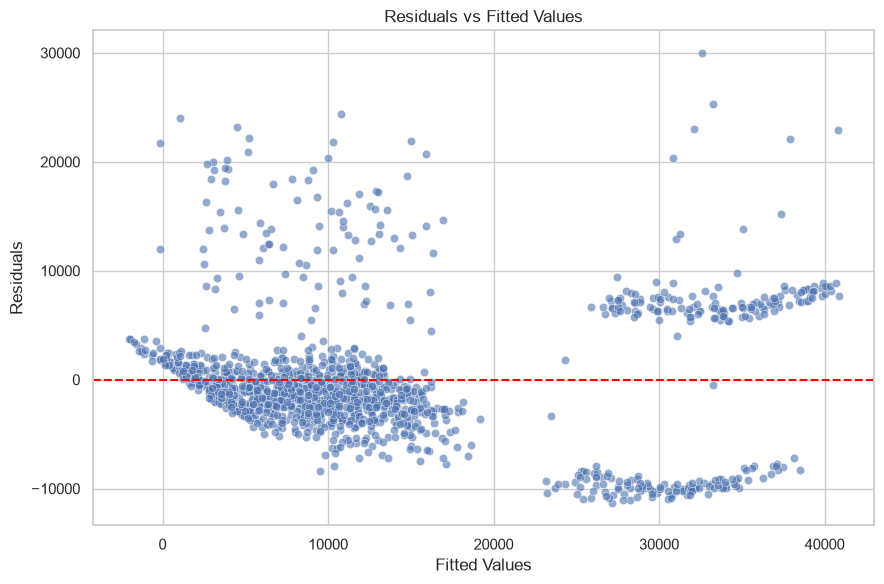

In [20]:
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(9, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()


### 17. Normality of Residuals — Q-Q Plot

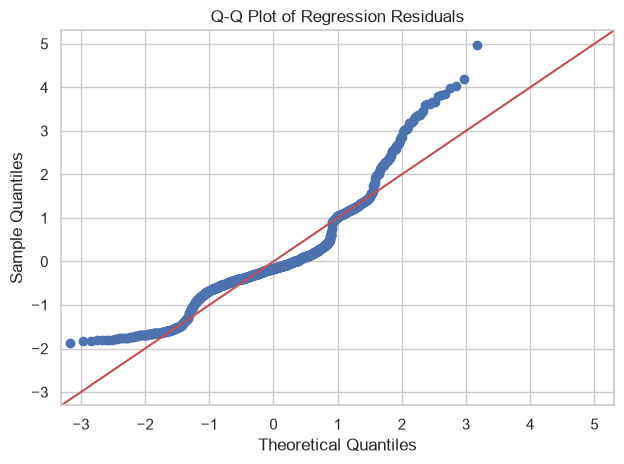

In [21]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.show()


### 18. Jarque-Bera Test

In [22]:
jb_result = jarque_bera(residuals)

print("Jarque-Bera Statistic:", jb_result.statistic)
print("p-value:", jb_result.pvalue)

if jb_result.pvalue > alpha:
    print("Fail to reject residual normality.")
else:
    print("Residuals show evidence of departure from normality.")


Jarque-Bera Statistic: 718.8872635707942
p-value: 7.863468661808985e-157
Residuals show evidence of departure from normality.


### 19. Multicollinearity — Variance Inflation Factor (VIF)

In [23]:
X_vif = X.drop(columns=["const"])

vif_table = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table.sort_values("VIF", ascending=False)

display(vif_table.round(4))


,Feature,VIF
1,bmi,11.3584
0,age,7.6870
6,region_southeast,2.2656
3,sex_male,2.0032
7,region_southwest,1.9607
5,region_northwest,1.8903
2,children,1.8099
4,smoker_yes,1.2612


# Part 3 — Prediction

### 20. Prediction with 95% Confidence and Prediction Intervals

In [24]:
# Demonstration using the first dataset observation.
# The Streamlit dashboard provides interactive user input.

example_input = X.iloc[[0]]

prediction = model.get_prediction(example_input)
prediction_result = prediction.summary_frame(alpha=0.05)

display(prediction_result)

print("mean = predicted average medical charge")
print("mean_ci_lower / mean_ci_upper = 95% confidence interval")
print("obs_ci_lower / obs_ci_upper = 95% prediction interval")


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,25293.713028,586.072539,24143.984879,26443.441177,13345.932791,37241.493266


mean = predicted average medical charge
mean_ci_lower / mean_ci_upper = 95% confidence interval
obs_ci_lower / obs_ci_upper = 95% prediction interval


# 21. Final Conclusions

After running all cells, summarize:

## Exploratory Data Analysis
- Main characteristics of the numerical variables.
- Distribution and skewness of charges.
- Important relationships visible in the plots.

## Hypothesis Test 1
- Test selected based on assumptions.
- Test statistic and p-value.
- Reject H₀ or Fail to Reject H₀.

## Hypothesis Test 2
- Chi-square statistic and p-value.
- Conclusion about smoking status and region.

## Regression
- R² and Adjusted R².
- Significant predictors.
- Interpretation of important coefficients.

## Diagnostic Checks
- Residual vs fitted pattern.
- Q-Q plot.
- Jarque-Bera result.
- VIF and multicollinearity findings.


# Part 3 — Interactive Streamlit Dashboard

The assignment also requires a Streamlit application with three tabs:

1. **Data Exploration**
2. **Hypothesis Testing Lab**
3. **Live Prediction & Diagnostics**

The following cell generates a complete `app.py` specifically configured to use:

`insurance(1).csv`


In [25]:
app_code = 'import streamlit as st\nimport pandas as pd\nimport numpy as np\nimport plotly.express as px\nimport matplotlib.pyplot as plt\nimport statsmodels.api as sm\n\nfrom scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, chi2_contingency, jarque_bera\nfrom statsmodels.stats.outliers_influence import variance_inflation_factor\n\nst.set_page_config(\n    page_title="Medical Insurance Dashboard",\n    layout="wide"\n)\n\n@st.cache_data\ndef load_data():\n    return pd.read_csv("insurance(1).csv")\n\n@st.cache_resource\ndef build_model(data):\n    model_df = pd.get_dummies(\n        data,\n        columns=["sex", "smoker", "region"],\n        drop_first=True,\n        dtype=int\n    )\n\n    X = model_df.drop(columns=["charges"])\n    y = model_df["charges"]\n    X = sm.add_constant(X)\n\n    model = sm.OLS(y, X).fit()\n    return model, X, y\n\ndf = load_data()\nmodel, X, y = build_model(df)\n\nst.title("Applied Statistical Modeling Dashboard")\nst.caption("Medical Insurance Costs Dataset")\n\ntab1, tab2, tab3 = st.tabs([\n    "📊 Data Exploration",\n    "🧪 Hypothesis Testing Lab",\n    "📈 Live Prediction & Diagnostics"\n])\n\nwith tab1:\n    st.header("Data Exploration")\n\n    st.sidebar.header("Filters")\n\n    age_range = st.sidebar.slider(\n        "Age Range",\n        int(df.age.min()),\n        int(df.age.max()),\n        (int(df.age.min()), int(df.age.max()))\n    )\n\n    selected_regions = st.sidebar.multiselect(\n        "Region",\n        sorted(df.region.unique()),\n        default=sorted(df.region.unique())\n    )\n\n    selected_smoker = st.sidebar.multiselect(\n        "Smoking Status",\n        sorted(df.smoker.unique()),\n        default=sorted(df.smoker.unique())\n    )\n\n    filtered = df[\n        df.age.between(age_range[0], age_range[1])\n        & df.region.isin(selected_regions)\n        & df.smoker.isin(selected_smoker)\n    ]\n\n    st.subheader("Dataset")\n    st.dataframe(filtered, use_container_width=True)\n\n    st.subheader("Summary Statistics")\n    st.dataframe(filtered.describe(include="all").T, use_container_width=True)\n\n    c1, c2 = st.columns(2)\n\n    with c1:\n        fig = px.histogram(\n            filtered,\n            x="charges",\n            nbins=30,\n            title="Distribution of Medical Charges"\n        )\n        st.plotly_chart(fig, use_container_width=True)\n\n    with c2:\n        fig = px.scatter(\n            filtered,\n            x="bmi",\n            y="charges",\n            color="smoker",\n            title="BMI vs Charges"\n        )\n        st.plotly_chart(fig, use_container_width=True)\n\n    corr = filtered.select_dtypes(include=np.number).corr()\n\n    fig = px.imshow(\n        corr,\n        text_auto=".2f",\n        title="Correlation Matrix",\n        aspect="auto"\n    )\n    st.plotly_chart(fig, use_container_width=True)\n\n\nwith tab2:\n    st.header("Hypothesis Testing Lab")\n    alpha = 0.05\n\n    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()\n    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()\n\n    st.subheader("Compare Two Groups")\n\n    factor = st.selectbox("Categorical Factor", categorical_cols)\n    metric = st.selectbox("Numerical Metric", numerical_cols)\n\n    groups = sorted(df[factor].dropna().unique())\n\n    group1 = st.selectbox("Group 1", groups)\n    group2 = st.selectbox(\n        "Group 2",\n        [g for g in groups if g != group1]\n    )\n\n    g1 = df.loc[df[factor] == group1, metric].dropna()\n    g2 = df.loc[df[factor] == group2, metric].dropna()\n\n    if len(g1) >= 3 and len(g2) >= 3:\n        sh1 = shapiro(g1)\n        sh2 = shapiro(g2)\n        lev = levene(g1, g2)\n\n        if sh1.pvalue > alpha and sh2.pvalue > alpha:\n            result = ttest_ind(\n                g1,\n                g2,\n                equal_var=(lev.pvalue > alpha)\n            )\n            test_name = "Two-Sample t-Test"\n        else:\n            result = mannwhitneyu(\n                g1,\n                g2,\n                alternative="two-sided"\n            )\n            test_name = "Mann-Whitney U Test"\n\n        st.write("Test Used:", test_name)\n        st.metric("Test Statistic", f"{result.statistic:.4f}")\n        st.metric("p-value", f"{result.pvalue:.6g}")\n\n        if result.pvalue < alpha:\n            st.success("Reject H₀ at α = 0.05.")\n        else:\n            st.info("Fail to Reject H₀ at α = 0.05.")\n\n    st.divider()\n\n    st.subheader("Chi-Square Test")\n\n    cat1 = st.selectbox(\n        "First Categorical Variable",\n        categorical_cols,\n        key="cat1"\n    )\n\n    cat2 = st.selectbox(\n        "Second Categorical Variable",\n        [c for c in categorical_cols if c != cat1],\n        key="cat2"\n    )\n\n    table = pd.crosstab(df[cat1], df[cat2])\n    chi2, p, dof, expected = chi2_contingency(table)\n\n    st.dataframe(table)\n    st.metric("Chi-Square Statistic", f"{chi2:.4f}")\n    st.metric("p-value", f"{p:.6g}")\n\n    if p < alpha:\n        st.success("Reject H₀: variables are associated.")\n    else:\n        st.info("Fail to Reject H₀: insufficient evidence of association.")\n\n\nwith tab3:\n    st.header("Live Prediction & Diagnostics")\n\n    age = st.slider(\n        "Age",\n        int(df.age.min()),\n        int(df.age.max()),\n        int(df.age.median())\n    )\n\n    bmi = st.number_input(\n        "BMI",\n        min_value=float(df.bmi.min()),\n        max_value=float(df.bmi.max()),\n        value=float(df.bmi.median())\n    )\n\n    children = st.slider(\n        "Children",\n        int(df.children.min()),\n        int(df.children.max()),\n        int(df.children.median())\n    )\n\n    sex = st.selectbox("Sex", sorted(df.sex.unique()))\n    smoker = st.selectbox("Smoking Status", sorted(df.smoker.unique()))\n    region = st.selectbox("Region", sorted(df.region.unique()))\n\n    if st.button("Predict Medical Charges"):\n        user_data = pd.DataFrame([{\n            "age": age,\n            "sex": sex,\n            "bmi": bmi,\n            "children": children,\n            "smoker": smoker,\n            "region": region\n        }])\n\n        encoded = pd.get_dummies(\n            user_data,\n            columns=["sex", "smoker", "region"],\n            drop_first=True,\n            dtype=int\n        )\n\n        encoded = encoded.reindex(\n            columns=[c for c in X.columns if c != "const"],\n            fill_value=0\n        )\n\n        encoded = sm.add_constant(encoded, has_constant="add")\n        encoded = encoded.reindex(columns=X.columns, fill_value=0)\n\n        pred = model.get_prediction(encoded).summary_frame(alpha=0.05).iloc[0]\n\n        st.success(f"Predicted Charges: ${pred[\'mean\']:,.2f}")\n\n        c1, c2 = st.columns(2)\n\n        c1.write("95% Confidence Interval")\n        c1.write(\n            f"${pred[\'mean_ci_lower\']:,.2f} to "\n            f"${pred[\'mean_ci_upper\']:,.2f}"\n        )\n\n        c2.write("95% Prediction Interval")\n        c2.write(\n            f"${pred[\'obs_ci_lower\']:,.2f} to "\n            f"${pred[\'obs_ci_upper\']:,.2f}"\n        )\n\n    st.divider()\n    st.subheader("Residual Diagnostics")\n\n    residuals = model.resid\n    fitted = model.fittedvalues\n\n    fig = px.scatter(\n        x=fitted,\n        y=residuals,\n        labels={"x": "Fitted Values", "y": "Residuals"},\n        title="Residuals vs Fitted Values"\n    )\n    fig.add_hline(y=0)\n    st.plotly_chart(fig, use_container_width=True)\n\n    qq = sm.qqplot(residuals, line="45", fit=True)\n    st.pyplot(qq)\n\n    jb = jarque_bera(residuals)\n    st.write(f"Jarque-Bera Statistic: {jb.statistic:.4f}")\n    st.write(f"Jarque-Bera p-value: {jb.pvalue:.6g}")\n\n    X_vif = X.drop(columns=["const"])\n\n    vif = pd.DataFrame({\n        "Feature": X_vif.columns,\n        "VIF": [\n            variance_inflation_factor(X_vif.values, i)\n            for i in range(X_vif.shape[1])\n        ]\n    })\n\n    st.subheader("Multicollinearity (VIF)")\n    st.dataframe(\n        vif.sort_values("VIF", ascending=False),\n        use_container_width=True\n    )\n'

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

requirements = """pandas
numpy
matplotlib
seaborn
scipy
statsmodels
streamlit
plotly
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("Files successfully created:")
print("1. app.py")
print("2. requirements.txt")
print()
print("To run the dashboard:")
print("pip install -r requirements.txt")
print("streamlit run app.py")


Files successfully created:
1. app.py
2. requirements.txt

To run the dashboard:
pip install -r requirements.txt
streamlit run app.py


# 22. Submission Checklist

Keep these files together:

```text
Lab4_Project/
│
├── Lab4_DS602_Based_On_Provided_Dataset.ipynb
├── insurance(1).csv
├── app.py
└── requirements.txt
```

Run the notebook from top to bottom.

For the Streamlit dashboard:

```bash
pip install -r requirements.txt
streamlit run app.py
```
